In [5]:


# ── IMPORTS ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── DEVICE ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {device}")

# ── OUTPUT FOLDER ─────────────────────────────────────────────────────────────
os.makedirs("vae_outputs", exist_ok=True)


Using device : cpu


In [6]:
#  HYPERPARAMETERS
INPUT_DIM    = 784        # 28 × 28 flattened MNIST image
HIDDEN_DIM   = 400        # hidden layer size
LATENT_DIM   = 20         # size of latent space z
BATCH_SIZE   = 128
EPOCHS       = 20
LEARNING_RATE = 1e-3
#  STEP 1 & 2 & 3 — VAE MODEL
#  (Encoder → Reparameterization → Decoder)
class VAE(nn.Module):
    """
    Variational Autoencoder on MNIST.

    Architecture:
        Encoder : 784 → 400 → (μ [20], log σ² [20])
        Decoder : 20  → 400 → 784  (sigmoid output)
    """

    def __init__(self, input_dim=INPUT_DIM,
                 hidden_dim=HIDDEN_DIM,
                 latent_dim=LATENT_DIM):
        super(VAE, self).__init__()

        # ── STEP 1 : ENCODER ─────────────────────────────────────────────────
        # Maps input x → hidden representation → two separate linear heads:
        #   fc_mu      : produces mean vector μ of size latent_dim
        #   fc_log_var : produces log-variance log(σ²) of size latent_dim
        #
        # We output log(σ²) instead of σ² because:
        #   • log-variance can be any real number (no positivity constraint)
        #   • numerically more stable during training

        self.encoder_fc  = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)   # → μ
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)   # → log(σ²)

        # ── STEP 3 : DECODER ─────────────────────────────────────────────────
        # Maps sampled latent vector z → hidden → reconstructed image
        # Sigmoid activation squashes output to [0,1] matching normalised pixels

        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    # ── STEP 1 : ENCODE ───────────────────────────────────────────────────────
    def encode(self, x):
        """
        Encode input x into latent distribution parameters.

        Args:
            x : Tensor of shape (batch, 784)

        Returns:
            mu      : mean of latent Gaussian,      shape (batch, latent_dim)
            log_var : log-variance of latent Gaussian, shape (batch, latent_dim)
        """
        h      = self.encoder_fc(x)
        mu     = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    # ── STEP 2 : REPARAMETERIZATION TRICK ────────────────────────────────────
    def reparameterize(self, mu, log_var):
        """
        Sample z ~ N(μ, σ²) using the reparameterization trick:

            z = μ + σ · ε,   where  ε ~ N(0, I)

        WHY THIS TRICK?
        Direct sampling from N(μ, σ²) is non-differentiable —
        gradients cannot flow back through a stochastic node.
        By rewriting z = μ + σ·ε with ε sampled from a FIXED
        distribution N(0,I), the randomness is moved OUTSIDE the
        computational graph.  Gradients now flow through μ and σ
        (the learned parameters) unobstructed.

        Args:
            mu      : mean,         shape (batch, latent_dim)
            log_var : log-variance,  shape (batch, latent_dim)

        Returns:
            z : sampled latent vector, shape (batch, latent_dim)
        """
        # σ = exp(0.5 · log σ²)
        std = torch.exp(0.5 * log_var)
        # ε ~ N(0, I)  — same shape as std, sampled on same device
        epsilon = torch.randn_like(std)
        # z = μ + σ · ε
        z = mu + std * epsilon
        return z

    # ── STEP 3 : DECODE ───────────────────────────────────────────────────────
    def decode(self, z):
        """
        Decode latent vector z back into image space.

        Args:
            z : Tensor of shape (batch, latent_dim)

        Returns:
            x_hat : reconstructed image, shape (batch, 784),  values in [0,1]
        """
        x_hat = self.decoder_fc(z)
        return x_hat

    # ── FORWARD PASS ──────────────────────────────────────────────────────────
    def forward(self, x):
        """
        Full forward pass: encode → reparameterize → decode.

        Returns:
            x_hat   : reconstructed image
            mu      : latent mean
            log_var : latent log-variance
        """
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        x_hat       = self.decode(z)
        return x_hat, mu, log_var

In [7]:
#  STEP 4 — LOSS FUNCTION

def vae_loss(x_hat, x, mu, log_var):
    """
    Total VAE Loss = Reconstruction Loss + KL Divergence Loss

    ── Reconstruction Loss ───────────────────────────────────────────────────
    Measures how well the decoder recreates the original input.
    We use Binary Cross-Entropy (BCE) because pixel values are in [0,1]
    (after normalization), matching the Bernoulli likelihood model:

        L_recon = BCE(x_hat, x)
                = -Σ [ x·log(x_hat) + (1-x)·log(1-x_hat) ]

    reduction='sum' sums over all pixels and batch;
    we later divide by batch_size for a per-sample average.

    ── KL Divergence Loss ────────────────────────────────────────────────────
    Regularises the latent space by keeping the learned posterior
    q(z|x) = N(μ, σ²) close to the standard Gaussian prior p(z) = N(0,I).

    Closed-form KL for two Gaussians:

        KL(q || p) = -0.5 · Σ [ 1 + log(σ²) - μ² - σ² ]

    A high KL penalty forces the encoder to avoid degenerate latent spaces
    where different classes collapse to the same region or spread too widely.

    Args:
        x_hat   : reconstructed image,    shape (batch, 784)
        x       : original image,          shape (batch, 784)
        mu      : latent mean,             shape (batch, latent_dim)
        log_var : latent log-variance,     shape (batch, latent_dim)

    Returns:
        total_loss : combined VAE loss (scalar)
        recon_loss : reconstruction component (scalar)
        kl_loss    : KL divergence component (scalar)
    """
    batch_size = x.size(0)

    # Reconstruction loss (BCE, summed over pixels then averaged over batch)
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum') / batch_size

    # KL Divergence: -0.5 · Σ(1 + log σ² - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch_size

    # Total loss
    total_loss = recon_loss + kl_loss

    return total_loss, recon_loss, kl_loss



In [8]:
#  DATA LOADING — MNIST

transform = transforms.Compose([
    transforms.ToTensor(),          # converts PIL → Tensor, scales [0,255]→[0,1]
])

train_dataset = datasets.MNIST(root='./data', train=True,
                                download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False,
                                download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"Train samples : {len(train_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")
print(f"Batches/epoch : {len(train_loader)}")


Train samples : 60,000
Test  samples : 10,000
Batches/epoch : 469


In [9]:
#  MODEL, OPTIMISER

model     = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Print architecture
print("\n── VAE Architecture ──────────────────────────────────")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {total_params:,}")
print("──────────────────────────────────────────────────────\n")

#  STEP 4 — TRAINING LOOP

def train_one_epoch(model, loader, optimizer, epoch):
    """
    One full pass over the training set.
    For each batch:
      1. Forward pass through VAE
      2. Compute reconstruction loss + KL divergence
      3. Combine into total VAE loss
      4. Backpropagate and update weights
    """
    model.train()

    total_loss_sum = 0.0
    recon_loss_sum = 0.0
    kl_loss_sum    = 0.0

    for batch_idx, (x, _) in enumerate(loader):

        # ── Prepare input ─────────────────────────────────────────────────
        x = x.view(-1, INPUT_DIM).to(device)   # flatten 28×28 → 784

        # ── Step 4a : Forward pass ────────────────────────────────────────
        x_hat, mu, log_var = model(x)

        # ── Step 4b : Compute losses ──────────────────────────────────────
        total_loss, recon_loss, kl_loss = vae_loss(x_hat, x, mu, log_var)

        # ── Step 4c : Backpropagation & weight update ─────────────────────
        optimizer.zero_grad()   # clear gradients from previous step
        total_loss.backward()   # compute gradients via autograd
        optimizer.step()        # Adam parameter update

        # ── Accumulate losses ─────────────────────────────────────────────
        total_loss_sum += total_loss.item()
        recon_loss_sum += recon_loss.item()
        kl_loss_sum    += kl_loss.item()

        # Print every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch [{epoch:02d}/{EPOCHS}] "
                  f"Batch [{batch_idx+1:03d}/{len(loader)}] "
                  f"| Total: {total_loss.item():8.3f} "
                  f"| Recon: {recon_loss.item():8.3f} "
                  f"| KL: {kl_loss.item():6.3f}")

    n_batches = len(loader)
    return (total_loss_sum / n_batches,
            recon_loss_sum / n_batches,
            kl_loss_sum    / n_batches)


def evaluate(model, loader):
    """Compute average losses on the validation/test set (no weight update)."""
    model.eval()

    total_loss_sum = 0.0
    recon_loss_sum = 0.0
    kl_loss_sum    = 0.0

    with torch.no_grad():
        for x, _ in loader:
            x = x.view(-1, INPUT_DIM).to(device)
            x_hat, mu, log_var = model(x)
            total_loss, recon_loss, kl_loss = vae_loss(x_hat, x, mu, log_var)
            total_loss_sum += total_loss.item()
            recon_loss_sum += recon_loss.item()
            kl_loss_sum    += kl_loss.item()

    n = len(loader)
    return total_loss_sum / n, recon_loss_sum / n, kl_loss_sum / n


# ── History containers ────────────────────────────────────────────────────────
history = {
    'train_total': [], 'train_recon': [], 'train_kl': [],
    'test_total' : [], 'test_recon' : [], 'test_kl' : []
}

print("  TRAINING VAE — MNIST")

for epoch in range(1, EPOCHS + 1):

    # ── Training ──────────────────────────────────────────────────────────────
    tr_total, tr_recon, tr_kl = train_one_epoch(model, train_loader,
                                                 optimizer, epoch)

    # ── Evaluation ────────────────────────────────────────────────────────────
    te_total, te_recon, te_kl = evaluate(model, test_loader)

    # ── Record history ────────────────────────────────────────────────────────
    history['train_total'].append(tr_total)
    history['train_recon'].append(tr_recon)
    history['train_kl'].append(tr_kl)
    history['test_total'].append(te_total)
    history['test_recon'].append(te_recon)
    history['test_kl'].append(te_kl)

    # ── Epoch summary ─────────────────────────────────────────────────────────
    print(f"\n  ── Epoch {epoch:02d}/{EPOCHS} Summary ──────────────────────────────")
    print(f"  TRAIN  | Total Loss: {tr_total:8.3f}  "
          f"| Reconstruction Loss: {tr_recon:8.3f}  "
          f"| KL Divergence Loss: {tr_kl:6.3f}")
    print(f"  TEST   | Total Loss: {te_total:8.3f}  "
          f"| Reconstruction Loss: {te_recon:8.3f}  "
          f"| KL Divergence Loss: {te_kl:6.3f}")
    print()

    # ── Save reconstructed samples every 5 epochs ─────────────────────────────
    if epoch % 5 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            sample_x, _ = next(iter(test_loader))
            sample_x    = sample_x[:16].view(-1, INPUT_DIM).to(device)
            recon_x, _, _ = model(sample_x)
            comparison = torch.cat([
                sample_x.view(-1, 1, 28, 28),
                recon_x.view(-1, 1, 28, 28)
            ])
            save_image(comparison.cpu(),
                       f"vae_outputs/recon_epoch_{epoch:02d}.png",
                       nrow=16)
print("  TRAINING COMPLETE")



── VAE Architecture ──────────────────────────────────
VAE(
  (encoder_fc): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_log_var): Linear(in_features=400, out_features=20, bias=True)
  (decoder_fc): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)
Trainable parameters : 652,824
──────────────────────────────────────────────────────

  TRAINING VAE — MNIST
  Epoch [01/20] Batch [100/469] | Total:  194.107 | Recon:  183.475 | KL: 10.632
  Epoch [01/20] Batch [200/469] | Total:  151.633 | Recon:  136.891 | KL: 14.741
  Epoch [01/20] Batch [300/469] | Total:  141.249 | Recon:  123.263 | KL: 17.986
  Epoch [01/20] Batch [400/469] | Total:  129.870 | Recon:  109.171 | KL: 20.698

  ── Epoch 01/20 Summary ──────────────────────────────
  TRAIN  | Tota

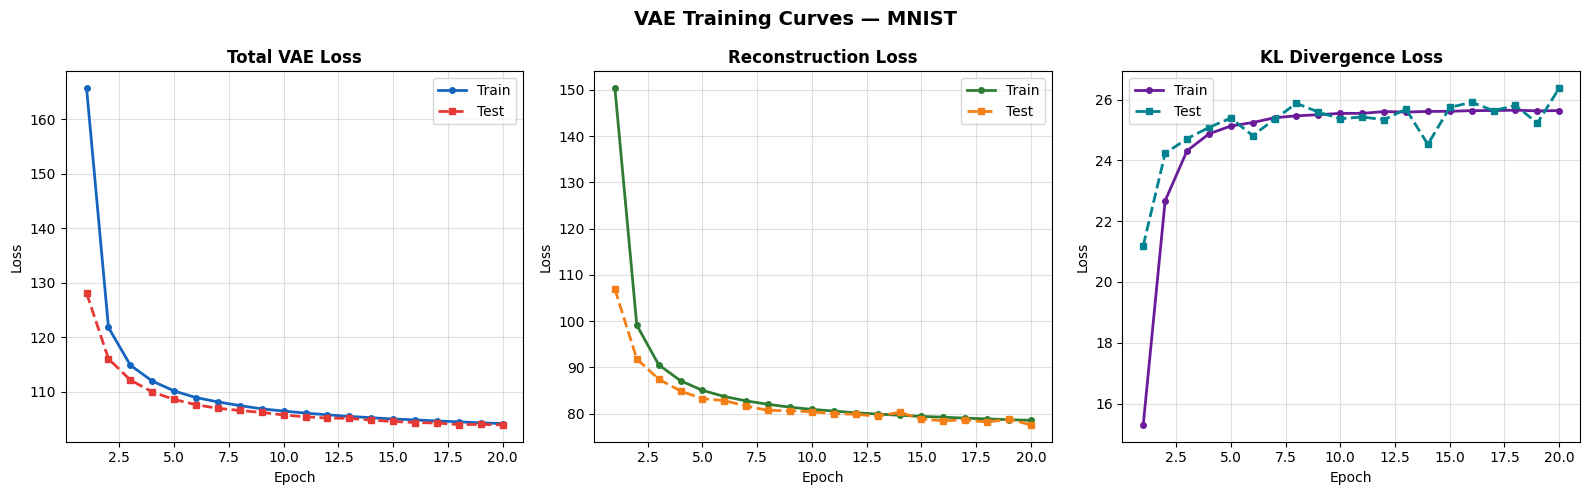

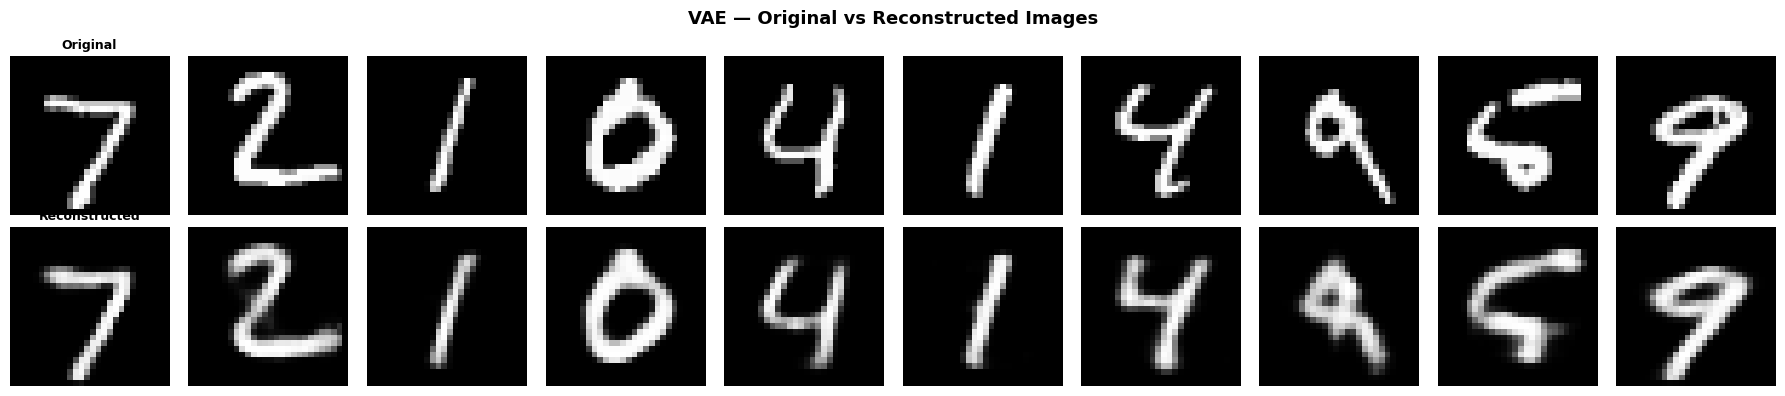

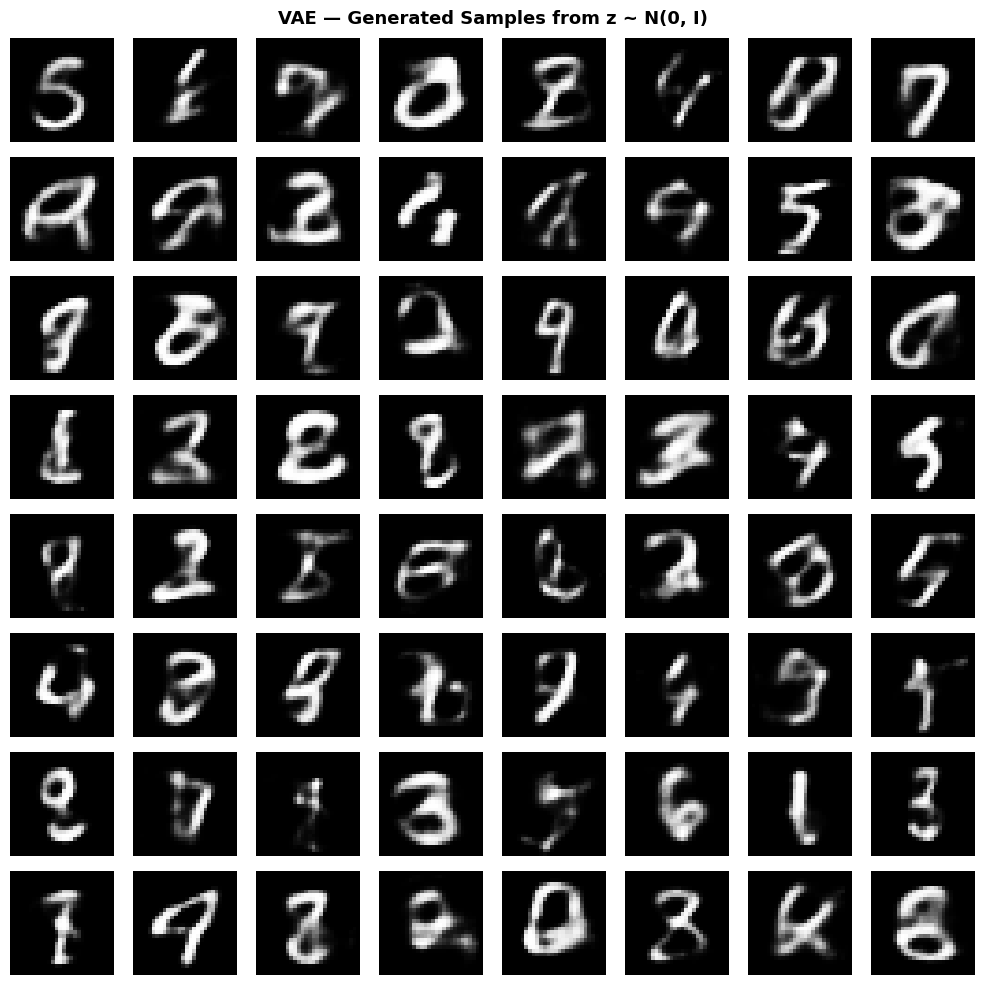

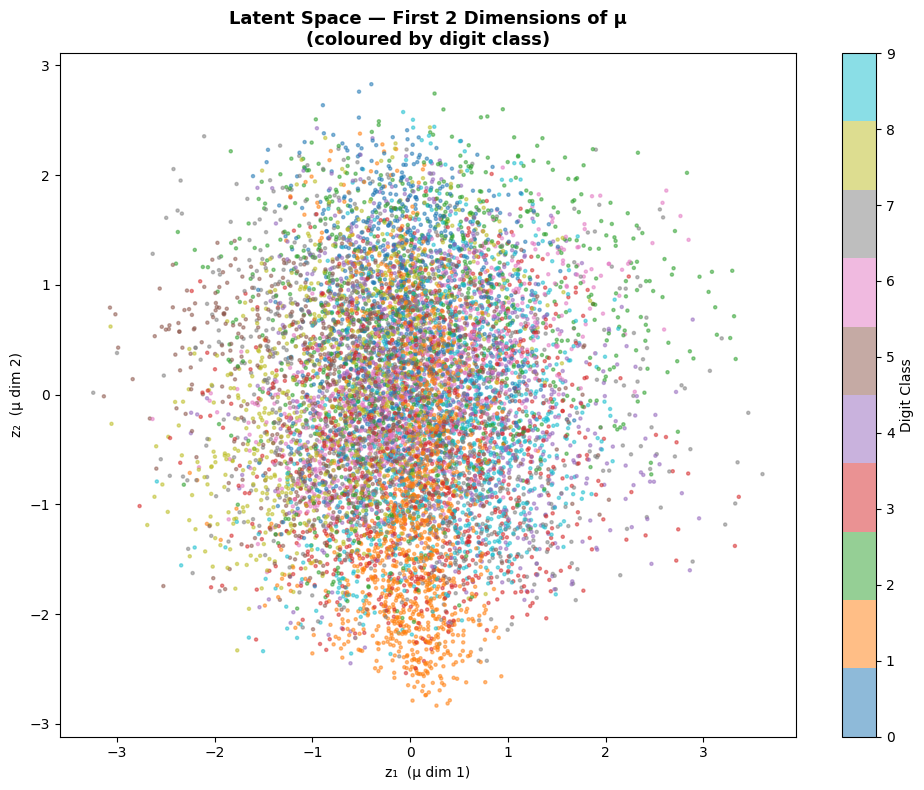

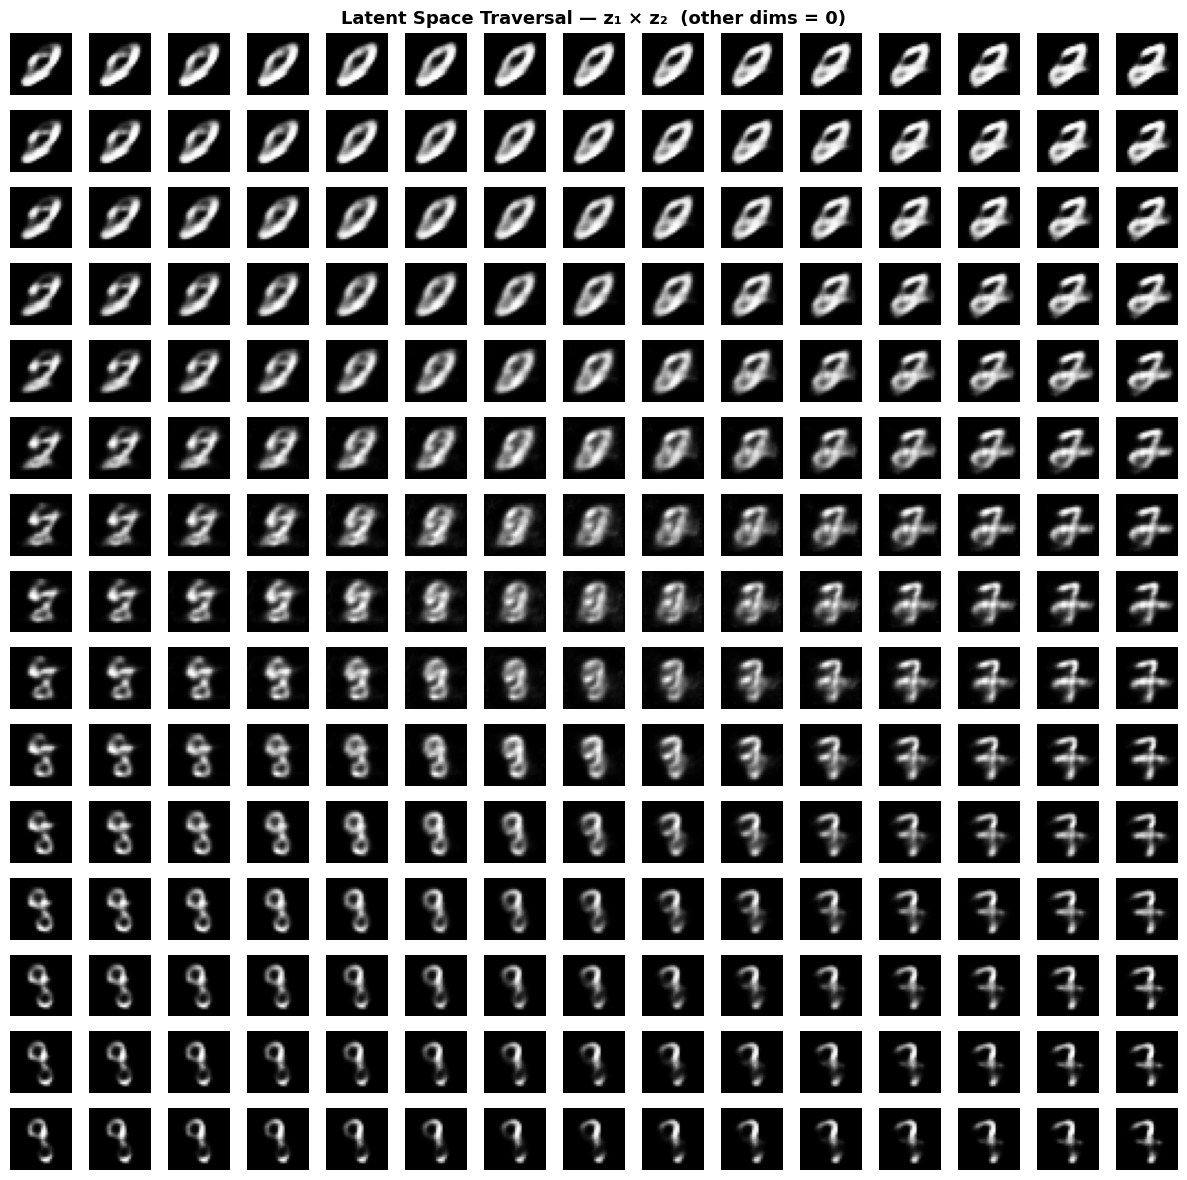

In [10]:
#  VISUALISATIONS

epochs_range = range(1, EPOCHS + 1)

# ── Plot 1: Loss Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, key, title, color_tr, color_te in [
    (axes[0], ('train_total', 'test_total'),
     'Total VAE Loss',         '#1565C0', '#E53935'),
    (axes[1], ('train_recon', 'test_recon'),
     'Reconstruction Loss',    '#2E7D32', '#F57F17'),
    (axes[2], ('train_kl',   'test_kl'),
     'KL Divergence Loss',     '#6A1B9A', '#00838F'),
]:
    tr_key, te_key = key
    ax.plot(epochs_range, history[tr_key], color=color_tr,
            linewidth=2, marker='o', markersize=4, label='Train')
    ax.plot(epochs_range, history[te_key], color=color_te,
            linewidth=2, marker='s', markersize=4, linestyle='--', label='Test')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.suptitle('VAE Training Curves — MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 2: Reconstruction Comparison ────────────────────────────────────────
model.eval()
with torch.no_grad():
    test_x, _ = next(iter(test_loader))
    test_x_flat = test_x[:10].view(-1, INPUT_DIM).to(device)
    recon, _, _ = model(test_x_flat)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for i in range(10):
    # Original
    axes[0, i].imshow(test_x[i].squeeze().numpy(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=9, fontweight='bold')
    # Reconstructed
    axes[1, i].imshow(recon[i].cpu().view(28, 28).numpy(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=9, fontweight='bold')

plt.suptitle('VAE — Original vs Reconstructed Images',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 3: Generated Samples (from random z ~ N(0,I)) ───────────────────────
model.eval()
with torch.no_grad():
    z_random = torch.randn(64, LATENT_DIM).to(device)
    generated = model.decode(z_random).cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze().numpy(), cmap='gray')
    ax.axis('off')

plt.suptitle('VAE — Generated Samples from z ~ N(0, I)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 4: 2D Latent Space (if LATENT_DIM >= 2, visualise first 2 dims) ─────
model.eval()
latent_mu_list = []
label_list     = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_flat = x_batch.view(-1, INPUT_DIM).to(device)
        mu, _  = model.encode(x_flat)
        latent_mu_list.append(mu[:, :2].cpu().numpy())
        label_list.append(y_batch.numpy())

latent_mu_all = np.concatenate(latent_mu_list, axis=0)
labels_all    = np.concatenate(label_list, axis=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    latent_mu_all[:, 0], latent_mu_all[:, 1],
    c=labels_all, cmap='tab10', alpha=0.5, s=5
)
plt.colorbar(scatter, label='Digit Class')
plt.title('Latent Space — First 2 Dimensions of μ\n(coloured by digit class)',
          fontsize=13, fontweight='bold')
plt.xlabel('z₁  (μ dim 1)')
plt.ylabel('z₂  (μ dim 2)')
plt.tight_layout()
plt.show()

# ── Plot 5: Latent Space Traversal (2D grid over dims 0 & 1) ─────────────────
model.eval()
n_grid   = 15
z_range  = 3.0
z1_vals  = np.linspace(-z_range, z_range, n_grid)
z2_vals  = np.linspace(-z_range, z_range, n_grid)

fig, axes = plt.subplots(n_grid, n_grid, figsize=(12, 12))
with torch.no_grad():
    for i, z2 in enumerate(z2_vals[::-1]):
        for j, z1 in enumerate(z1_vals):
            z_sample              = torch.zeros(1, LATENT_DIM).to(device)
            z_sample[0, 0]        = z1
            z_sample[0, 1]        = z2
            img = model.decode(z_sample).cpu().view(28, 28).numpy()
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

plt.suptitle('Latent Space Traversal — z₁ × z₂  (other dims = 0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
#  FINAL SUMMARY
print("  FINAL RESULTS SUMMARY")
print(f"  LATENT DIM       : {LATENT_DIM}")
print(f"  EPOCHS TRAINED   : {EPOCHS}")
print(f"  BATCH SIZE       : {BATCH_SIZE}")
print(f"  LEARNING RATE    : {LEARNING_RATE}")
print()
print("  ── Final Epoch Test Metrics ───────────────────────────")
print(f"  Total Loss       : {history['test_total'][-1]:.4f}")
print(f"  Reconstruction   : {history['test_recon'][-1]:.4f}")
print(f"  KL Divergence    : {history['test_kl'][-1]:.4f}")
print()
print("  ── Best Epoch (lowest test total loss) ────────────────")
best_ep = int(np.argmin(history['test_total'])) + 1
print(f"  Best Epoch       : {best_ep}")
print(f"  Best Total Loss  : {min(history['test_total']):.4f}")
print(f"  Best Recon Loss  : {history['test_recon'][best_ep-1]:.4f}")
print(f"  Best KL Loss     : {history['test_kl'][best_ep-1]:.4f}")
print()

  FINAL RESULTS SUMMARY
  LATENT DIM       : 20
  EPOCHS TRAINED   : 20
  BATCH SIZE       : 128
  LEARNING RATE    : 0.001

  ── Final Epoch Test Metrics ───────────────────────────
  Total Loss       : 103.9412
  Reconstruction   : 77.5665
  KL Divergence    : 26.3747

  ── Best Epoch (lowest test total loss) ────────────────
  Best Epoch       : 20
  Best Total Loss  : 103.9412
  Best Recon Loss  : 77.5665
  Best KL Loss     : 26.3747

